In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load dataset

file_path = "../data/Telco_customer_churn.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 7043
Columns: 33


In [4]:
# Dataset overview

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())


Dataset Shape: (7043, 33)

Column Names:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

First 5 Rows:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
# Data types and missing values

print("Data Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

Data Types:


CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object


Missing Values:


CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [6]:
# Basic statistical summary

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Data Cleaning

# Create a copy of the original dataset
df_clean = df.copy()

# Check blank values in Total Charges
print("Blank values in Total Charges:",
      (df_clean["Total Charges"].astype(str).str.strip() == "").sum())

# Convert Total Charges to numeric
df_clean["Total Charges"] = pd.to_numeric(
    df_clean["Total Charges"],
    errors="coerce"
)

# Check missing values after conversion
print("\nMissing values after converting Total Charges:")
print(df_clean["Total Charges"].isnull().sum())

# Remove rows with missing Total Charges
df_clean = df_clean.dropna(subset=["Total Charges"]).copy()

print("\nDataset shape after cleaning:", df_clean.shape)

Blank values in Total Charges: 11

Missing values after converting Total Charges:
11

Dataset shape after cleaning: (7032, 33)


In [8]:
# Check for duplicate customers

print("Duplicate Customer IDs:",
      df_clean["CustomerID"].duplicated().sum())

print("Duplicate rows:",
      df_clean.duplicated().sum())

Duplicate Customer IDs: 0
Duplicate rows: 0


In [9]:
# Remove unnecessary columns

columns_to_drop = [
    "Count",
    "Country",
    "State",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Score",
    "Churn Reason"
]

df_clean = df_clean.drop(columns=columns_to_drop)

print("Remaining columns:", df_clean.shape[1])
print(df_clean.columns.tolist())

Remaining columns: 25
['CustomerID', 'City', 'Zip Code', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'CLTV']


In [10]:
# Final cleaning check

print("Final dataset shape:", df_clean.shape)

print("\nMissing values:")
display(df_clean.isnull().sum())

print("\nData types:")
display(df_clean.dtypes)

Final dataset shape: (7032, 25)

Missing values:


CustomerID           0
City                 0
Zip Code             0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
CLTV                 0
dtype: int64


Data types:


CustomerID            object
City                  object
Zip Code               int64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
CLTV                   int64
dtype: object

-----------------------------------------------------------------------------------------------------------------------------

In [11]:
# Overall churn analysis

churn_counts = df_clean["Churn Label"].value_counts()

print("Customer Churn Distribution:")
display(churn_counts)

# Calculate churn rate
churn_rate = df_clean["Churn Value"].mean() * 100

print(f"\nOverall Churn Rate: {churn_rate:.2f}%")

Customer Churn Distribution:


Churn Label
No     5163
Yes    1869
Name: count, dtype: int64


Overall Churn Rate: 26.58%


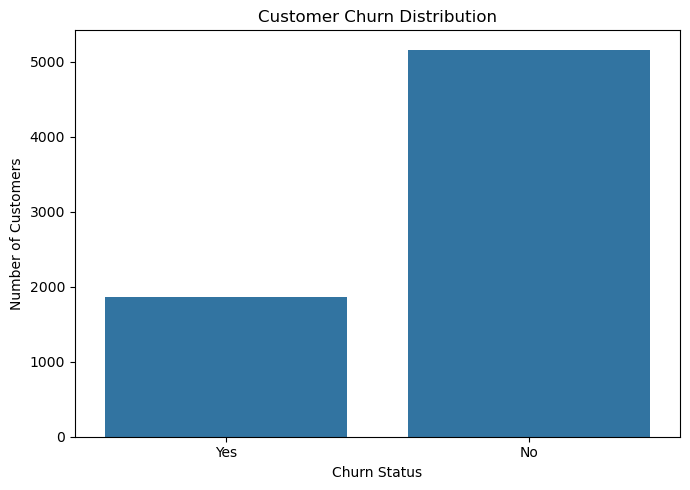

In [12]:
# Churn distribution visualization

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------------------

In [13]:
# Churn rate by contract type

contract_churn = (
    df_clean.groupby("Contract")["Churn Value"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Churn Rate by Contract Type:")
display(contract_churn)

Churn Rate by Contract Type:


Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn Value, dtype: float64

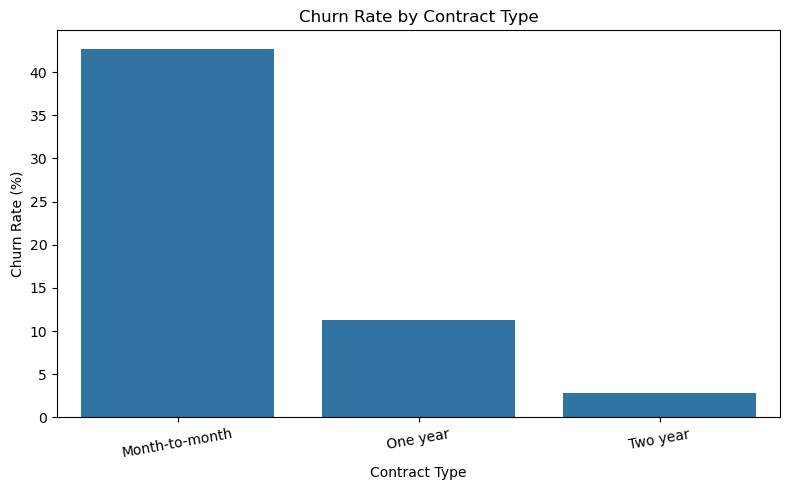

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------------------

In [15]:
# Create tenure groups

df_clean["Tenure Group"] = pd.cut(
    df_clean["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

tenure_churn = (
    df_clean.groupby("Tenure Group", observed=False)["Churn Value"]
    .mean()
    .mul(100)
)

print("Churn Rate by Tenure Group:")
display(tenure_churn)

Churn Rate by Tenure Group:


Tenure Group
0-12 Months     47.678161
13-24 Months    28.710938
25-48 Months    20.388959
49-72 Months     9.513176
Name: Churn Value, dtype: float64

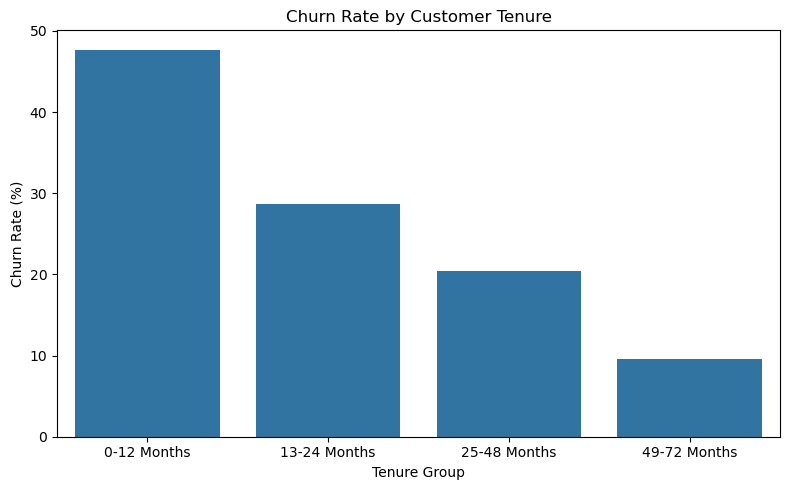

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------------------

In [17]:
# Churn rate by internet service

internet_churn = (
    df_clean.groupby("Internet Service")["Churn Value"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Churn Rate by Internet Service:")
display(internet_churn)

Churn Rate by Internet Service:


Internet Service
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn Value, dtype: float64

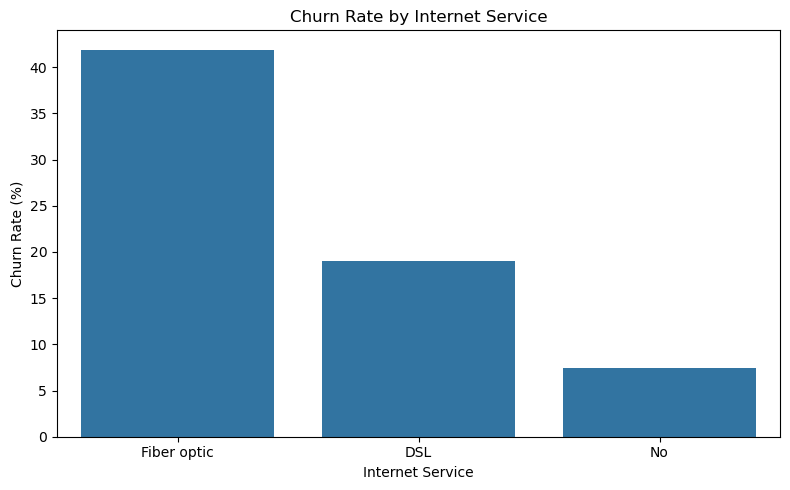

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------------------

In [19]:
# Monthly charges comparison by churn status

monthly_charges_churn = (
    df_clean.groupby("Churn Label")["Monthly Charges"]
    .agg(["mean", "median"])
)

print("Monthly Charges by Churn Status:")
display(monthly_charges_churn)

Monthly Charges by Churn Status:


,mean,median
Churn Label,,
No,61.307408,64.45
Yes,74.441332,79.65


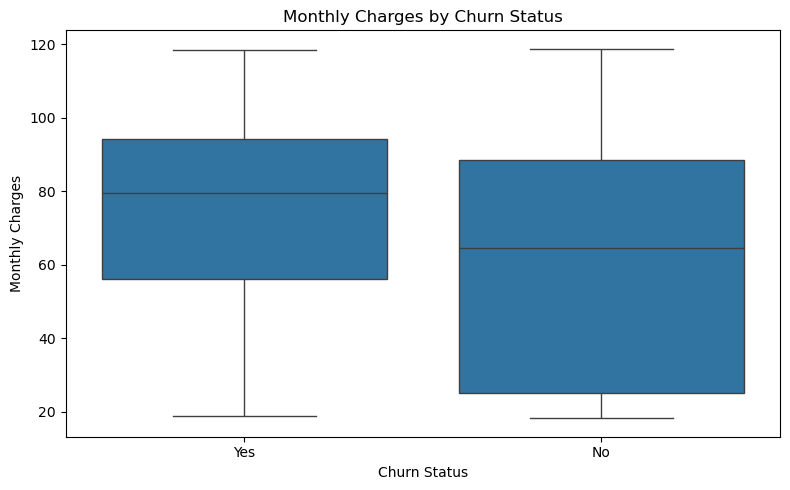

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------------------

In [21]:
# Churn rate by payment method

payment_churn = (
    df_clean.groupby("Payment Method")["Churn Value"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Churn Rate by Payment Method:")
display(payment_churn)

Churn Rate by Payment Method:


Payment Method
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn Value, dtype: float64

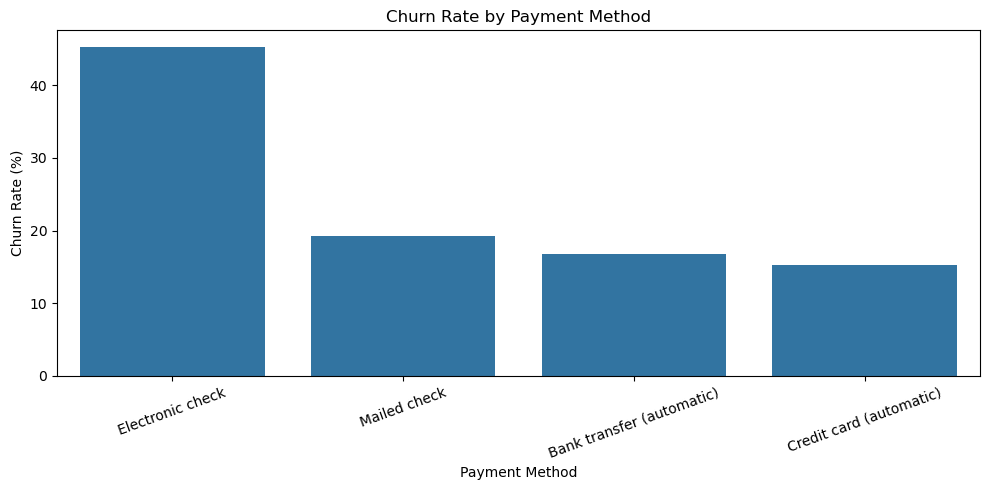

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------------------

In [23]:
# Churn rate by additional services

service_columns = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support"
]

service_results = {}

for column in service_columns:
    service_results[column] = (
        df_clean.groupby(column)["Churn Value"]
        .mean()
        .mul(100)
    )

service_churn = pd.DataFrame(service_results)

display(service_churn)

,Online Security,Online Backup,Device Protection,Tech Support
No,41.778667,39.941691,39.140271,41.647465
No internet service,7.434211,7.434211,7.434211,7.434211
Yes,14.640199,21.567010,22.539289,15.196078


-----------------------------------------------------------------------------------------------------------------------------

In [24]:
# Churn rate by customer demographics

demographic_columns = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents"
]

for column in demographic_columns:
    print(f"\nChurn Rate by {column}:")
    
    result = (
        df_clean.groupby(column)["Churn Value"]
        .mean()
        .mul(100)
        .round(2)
    )
    
    display(result)


Churn Rate by Gender:


Gender
Female    26.96
Male      26.20
Name: Churn Value, dtype: float64


Churn Rate by Senior Citizen:


Senior Citizen
No     23.65
Yes    41.68
Name: Churn Value, dtype: float64


Churn Rate by Partner:


Partner
No     32.98
Yes    19.72
Name: Churn Value, dtype: float64


Churn Rate by Dependents:


Dependents
No     32.58
Yes     6.54
Name: Churn Value, dtype: float64

-----------------------------------------------------------------------------------------------------------------------------

In [26]:
# Prepare data for machine learning

ml_df = df_clean.copy()

# Remove identifier and target-related columns
ml_df = ml_df.drop(columns=["CustomerID", "Churn Value"])

# Convert target to binary
ml_df["Churn Label"] = ml_df["Churn Label"].map({
    "Yes": 1,
    "No": 0
})

print("ML dataset shape:", ml_df.shape)
display(ml_df.head())

ML dataset shape: (7032, 24)


,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV,Tenure Group
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239,0-12 Months
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701,0-12 Months
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372,0-12 Months
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003,25-48 Months
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340,49-72 Months


-----------------------------------------------------------------------------------------------------------------------------

In [27]:
# Separate features and target

X = ml_df.drop(columns=["Churn Label"])
y = ml_df["Churn Label"]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features: (7032, 23)
Target: (7032,)

Target distribution:
Churn Label
0    5163
1    1869
Name: count, dtype: int64


In [28]:
# Identify numerical and categorical columns

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Zip Code', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

Categorical features:
['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Tenure Group']


-----------------------------------------------------------------------------------------------------------------------------

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5625
Testing samples: 1407


-----------------------------------------------------------------------------------------------------------------------------

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [31]:
# Train the churn prediction model

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [32]:
# Model predictions

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


C:\Users\mohit\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\mohit\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [33]:
# Classification metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7932
Precision: 0.6285
Recall   : 0.5428
F1 Score : 0.5825
ROC-AUC  : 0.8329

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



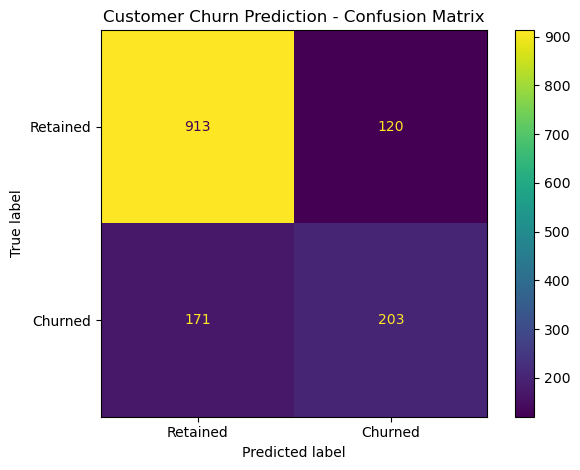

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Retained", "Churned"]
)

disp.plot()

plt.title("Customer Churn Prediction - Confusion Matrix")
plt.tight_layout()
plt.show()

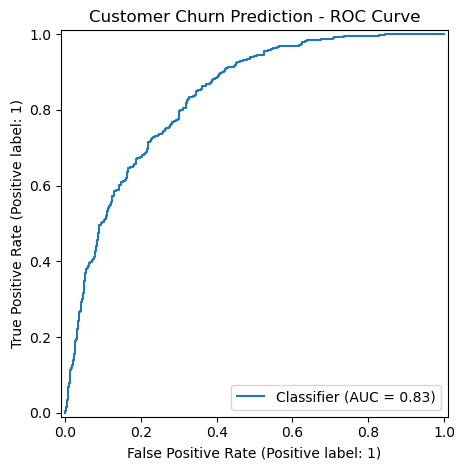

In [35]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba
)

plt.title("Customer Churn Prediction - ROC Curve")
plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------------------

In [36]:
# Create a cleaner feature set for churn prediction

ml_df_model = df_clean.copy()

# Remove identifier, geographic and target-derived columns
columns_to_remove = [
    "CustomerID",
    "City",
    "Zip Code",
    "CLTV",
    "Churn Value",
    "Tenure Group"
]

ml_df_model = ml_df_model.drop(columns=columns_to_remove)

# Convert target to binary
ml_df_model["Churn Label"] = ml_df_model["Churn Label"].map({
    "Yes": 1,
    "No": 0
})

X = ml_df_model.drop(columns=["Churn Label"])
y = ml_df_model["Churn Label"]

print("Clean model dataset:", ml_df_model.shape)

Clean model dataset: (7032, 20)


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

model.fit(X_train, y_train)

print("Clean model trained successfully.")

Clean model trained successfully.


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8045
Precision: 0.6410
Recall   : 0.6016
F1 Score : 0.6207
ROC-AUC  : 0.8432

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [39]:
# Extract feature importance from Logistic Regression

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute importance
feature_importance["Absolute Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute Importance",
    ascending=False
)

print("Top 15 Most Important Features:")
display(feature_importance.head(15))

Top 15 Most Important Features:


,Feature,Coefficient,Absolute Importance
6,cat__Dependents_Yes,-1.614298,1.614298
0,num__Tenure Months,-1.375920,1.375920
25,cat__Contract_Two year,-1.327126,1.327126
10,cat__Internet Service_Fiber optic,0.948032,0.948032
24,cat__Contract_One year,-0.783500,0.783500
2,num__Total Charges,0.639643,0.639643
7,cat__Phone Service_Yes,-0.508867,0.508867
28,cat__Payment Method_Electronic check,0.377710,0.377710
13,cat__Online Security_Yes,-0.374101,0.374101
19,cat__Tech Support_Yes,-0.358096,0.358096


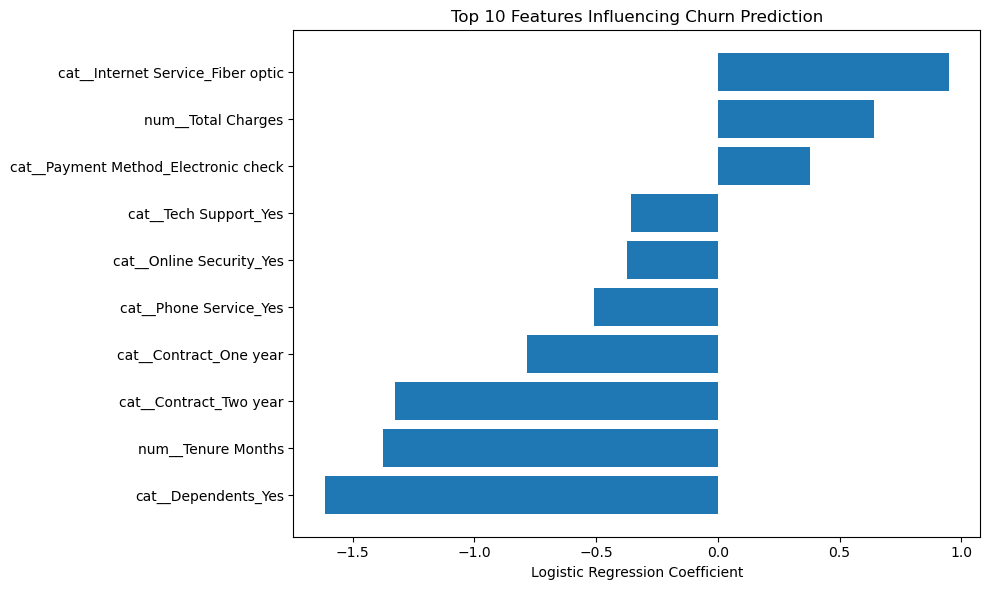

In [40]:
# Visualize top 10 features

top_features = feature_importance.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top 10 Features Influencing Churn Prediction")
plt.xlabel("Logistic Regression Coefficient")

plt.tight_layout()
plt.show()

In [41]:
# Business Insights and Recommendations

print("KEY BUSINESS INSIGHTS")
print("=" * 60)

print("\n1. Contract Type")
print("Month-to-month customers have the highest churn rate (~42.8%).")
print("One-year contracts have much lower churn (~11.3%).")
print("Two-year contracts have the lowest churn (~2.8%).")

print("\n2. Customer Tenure")
print("Customers with 0-12 months tenure have the highest churn (~47.7%).")
print("Churn decreases consistently as customer tenure increases.")

print("\n3. Internet Service")
print("Fiber optic customers have the highest churn (~41.9%).")
print("DSL customers have lower churn (~19.0%).")
print("Customers without internet service have the lowest churn (~7.4%).")

print("\n4. Payment Method")
print("Electronic check customers have the highest churn (~45.3%).")
print("Customers using automatic payment methods have substantially lower churn.")

print("\n5. Customer Profile")
print("Senior citizens have higher churn (~41.7%) than non-senior citizens (~23.7%).")
print("Customers without partners have higher churn (~33.0%) than customers with partners (~19.7%).")
print("Customers without dependents have substantially higher churn (~32.6%) than customers with dependents (~6.5%).")

print("\n6. Monthly Charges")
print("Churned customers have higher average monthly charges (~$74.44).")
print("Retained customers have lower average monthly charges (~$61.31).")

print("\n7. Model Findings")
print("The model achieved ROC-AUC of 0.8432.")
print("Tenure, contract type and dependents are among the strongest factors associated with lower churn.")
print("Fiber optic service and electronic-check payment are among the stronger factors associated with higher churn.")

KEY BUSINESS INSIGHTS

1. Contract Type
Month-to-month customers have the highest churn rate (~42.8%).
One-year contracts have much lower churn (~11.3%).
Two-year contracts have the lowest churn (~2.8%).

2. Customer Tenure
Customers with 0-12 months tenure have the highest churn (~47.7%).
Churn decreases consistently as customer tenure increases.

3. Internet Service
Fiber optic customers have the highest churn (~41.9%).
DSL customers have lower churn (~19.0%).
Customers without internet service have the lowest churn (~7.4%).

4. Payment Method
Electronic check customers have the highest churn (~45.3%).
Customers using automatic payment methods have substantially lower churn.

5. Customer Profile
Senior citizens have higher churn (~41.7%) than non-senior citizens (~23.7%).
Customers without partners have higher churn (~33.0%) than customers with partners (~19.7%).
Customers without dependents have substantially higher churn (~32.6%) than customers with dependents (~6.5%).

6. Monthly 

In [42]:
print("BUSINESS RECOMMENDATIONS")
print("=" * 60)

recommendations = [
    ["1", "Target month-to-month customers",
     "Offer discounts or incentives to encourage 1-year or 2-year contracts."],

    ["2", "Focus on new customers",
     "Create onboarding programs and early-retention offers during the first 12 months."],

    ["3", "Investigate fiber optic churn",
     "Analyze pricing, service quality and customer support issues among fiber optic customers."],

    ["4", "Promote automatic payments",
     "Encourage electronic-check customers to switch to automatic payment methods."],

    ["5", "Prioritize high-risk customers",
     "Use the churn prediction model to identify customers who are likely to leave."],

    ["6", "Improve support services",
     "Investigate whether customers without online security or technical support require targeted offers."],

    ["7", "Monitor high monthly charges",
     "Review customers with higher monthly charges and provide suitable plans or retention offers."]
]

recommendations_df = pd.DataFrame(
    recommendations,
    columns=["#", "Area", "Recommendation"]
)

display(recommendations_df)

BUSINESS RECOMMENDATIONS


,#,Area,Recommendation
0,1,Target month-to-month customers,Offer discounts or incentives to encourage 1-y...
1,2,Focus on new customers,Create onboarding programs and early-retention...
2,3,Investigate fiber optic churn,"Analyze pricing, service quality and customer ..."
3,4,Promote automatic payments,Encourage electronic-check customers to switch...
4,5,Prioritize high-risk customers,Use the churn prediction model to identify cus...
5,6,Improve support services,Investigate whether customers without online s...
6,7,Monitor high monthly charges,Review customers with higher monthly charges a...


In [43]:
import joblib
import os

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save the complete preprocessing + model pipeline
joblib.dump(model, "../models/churn_model.pkl")

print("Model saved successfully!")
print("Location: models/churn_model.pkl")

Model saved successfully!
Location: models/churn_model.pkl


In [44]:
import os

model_path = "../models/churn_model.pkl"

if os.path.exists(model_path):
    print("Model file exists!")
    print(f"File size: {os.path.getsize(model_path) / 1024:.2f} KB")
else:
    print("Model file was not found.")

Model file exists!
File size: 7.92 KB
